# Cheese Quality Assessment — Kinetic Models
**Gompertz · Luedeking-Piret · Monod**

**Question centrale :** Ces trois modèles permettent-ils de construire un outil analytique fiable pour évaluer la qualité d'un fromage à partir des seules données de pH ?

| Session | Date | Instrument | Ren­dement |
|---------|------|------------|----------|
| S1 — Fromage 3 | 28 avr. 2026 | Hanna FC2020 (PHLOT001) | 12.17 % |
| S2 — PHLOT002  |  5 mai  2026 | Hanna FC2020 (PHLOT002) | 11.8 % |

> Seules les sondes Hannah sont retenues : ce sont les seules avec température mesurée → correction de Nernst précise → pH fiable.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
})

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

def nernst_correct(pH_meas, T_meas_C, T_cal_C=25.0, pH_iso=7.0):
    return pH_iso + (pH_meas - pH_iso) * ((T_meas_C + 273.15) / (T_cal_C + 273.15))

def resample_1min(series):
    return series.resample('1min').median().dropna()

print('Setup OK')

Setup OK


---
## 0. Chargement des données

In [2]:
# ── Session 1 — Hanna PHLOT001 (28 avr.) ────────────────────────────────────
df3_raw = pd.read_csv(
    'data/trace pH fromage 3_28042026_hannah.csv',
    skiprows=20, header=None,
    names=['_','rec','date','time','pH','u1','mV','u2','temp_C','u3','_2'],
    usecols=['date','time','pH','mV','temp_C'], encoding='latin-1',
)
df3_raw['datetime'] = pd.to_datetime(
    df3_raw['date'].str.strip() + ' ' + df3_raw['time'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)
for col in ['pH','mV','temp_C']:
    df3_raw[col] = pd.to_numeric(df3_raw[col], errors='coerce')
s1 = df3_raw[['datetime','pH','temp_C']].dropna().set_index('datetime').sort_index()
s1 = s1[(s1['pH'] >= 3.5) & (s1['pH'] <= 7.0)].copy()

# Resample + Nernst
s1_pH   = resample_1min(s1['pH'])
s1_temp = resample_1min(s1['temp_C'])
idx1    = s1_pH.index.intersection(s1_temp.index)
s1_corr = pd.Series(
    nernst_correct(s1_pH.loc[idx1].values, s1_temp.loc[idx1].values),
    index=idx1
)

# ── Session 2 — Hanna PHLOT002 (5 mai) ──────────────────────────────────────
df_ph = pd.read_csv('data_5_mais/trace_pH_hannah_05052026.csv',
                    index_col='datetime', parse_dates=True)
df_ph = df_ph[(df_ph['pH'] >= 3.5) & (df_ph['pH'] <= 7.0)].copy()

s2_pH   = resample_1min(df_ph['pH'])
s2_temp = resample_1min(df_ph['temp_C'])
idx2    = s2_pH.index.intersection(s2_temp.index)
s2_corr = pd.Series(
    nernst_correct(s2_pH.loc[idx2].values, s2_temp.loc[idx2].values),
    index=idx2
)

SESSIONS = {
    'S1 — PHLOT001 (28 avr.)  yield=12.17%': {'series': s1_corr, 'yield': 12.17, 'color': 'seagreen'},
    'S2 — PHLOT002 (5 mai)    yield=11.8%' : {'series': s2_corr, 'yield': 11.80, 'color': 'steelblue'},
}

for name, d in SESSIONS.items():
    s = d['series']
    print(f'{name} | {len(s)} pts | {s.index[0]} → {s.index[-1]}')

S1 — PHLOT001 (28 avr.)  yield=12.17% | 251 pts | 2026-04-28 12:08:00 → 2026-04-28 16:18:00
S2 — PHLOT002 (5 mai)    yield=11.8% | 286 pts | 2026-05-05 11:23:00 → 2026-05-05 16:08:00


---
## 1. Modèle de Gompertz

$$A(t) = A_{max} \cdot \exp\!\left(-\exp\!\left[\frac{\mu_{max}\cdot e}{A_{max}}(\lambda - t) + 1\right]\right)$$

| Paramètre | Signification biologique |
|-----------|-------------------------|
| $A_{max}$ | Acidification totale maximale (ΔpH) |
| $\mu_{max}$ | Vitesse maximale d'acidification (ΔpH/h) |
| $\lambda$ | Temps de latence — délai avant acidification active (h) |

S1 — PHLOT001 (28 avr.)  yield=12.17%
  A_max = 0.800 ΔpH | μ_max = 0.467 ΔpH/h | λ = 0.00 h | R² = 0.782
S2 — PHLOT002 (5 mai)    yield=11.8%
  A_max = 1.310 ΔpH | μ_max = 0.416 ΔpH/h | λ = 0.00 h | R² = 0.942


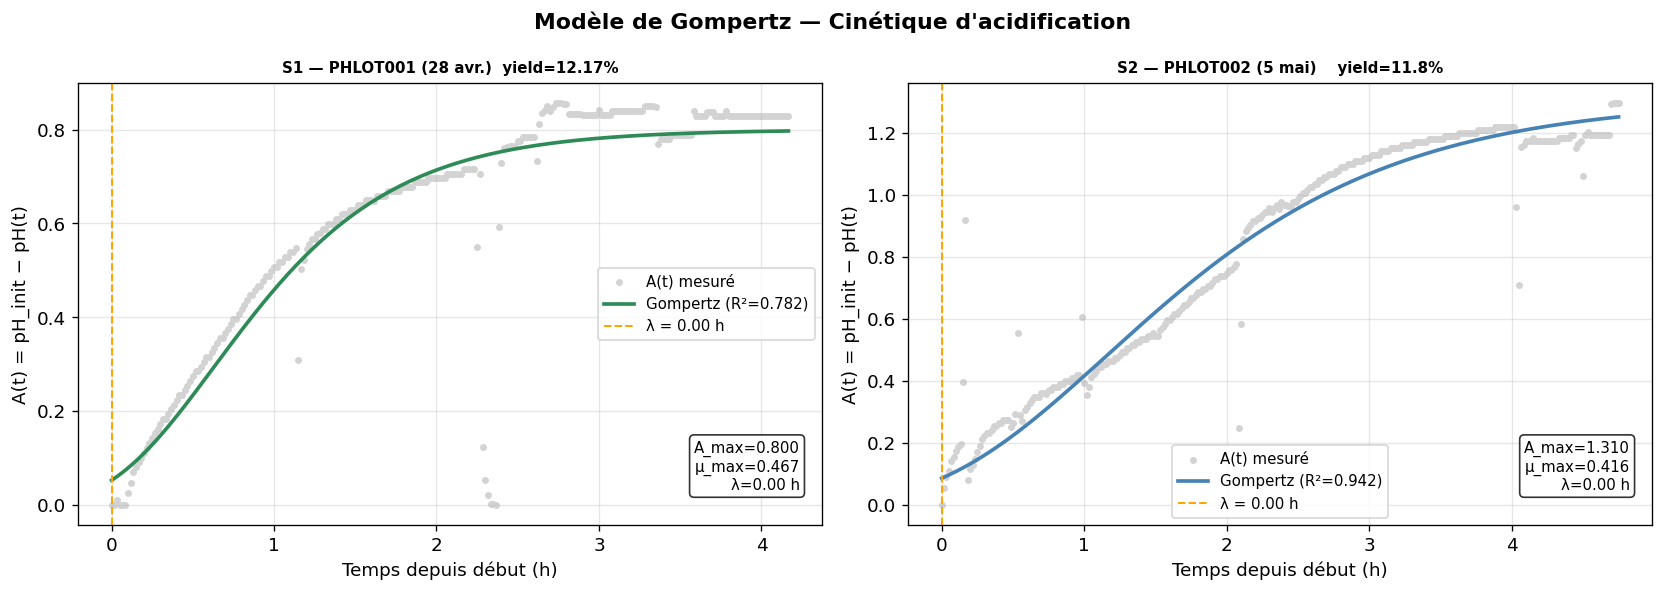

In [3]:
def gompertz(t, A_max, mu_max, lam):
    return A_max * np.exp(-np.exp((mu_max * np.e / A_max) * (lam - t) + 1))

def fit_gompertz(ph_series):
    t = (ph_series.index - ph_series.index[0]).total_seconds() / 3600
    A = ph_series.values[0] - ph_series.values
    A = np.clip(A, 0, None)
    p0 = [A.max(), 0.5, t[np.argmax(np.gradient(A, t))]]
    try:
        popt, _ = curve_fit(gompertz, t, A, p0=p0,
                            bounds=([0,0,0],[5,10,10]), maxfev=20000)
        A_pred = gompertz(t, *popt)
        ss_res = np.sum((A - A_pred)**2)
        ss_tot = np.sum((A - A.mean())**2)
        r2 = 1 - ss_res/ss_tot
        return dict(A_max=popt[0], mu_max=popt[1], lam=popt[2],
                    r2=r2, t=t, A=A, A_pred=A_pred)
    except Exception as e:
        print(f'  Gompertz fit failed: {e}')
        return None

gompertz_results = {}
for name, d in SESSIONS.items():
    res = fit_gompertz(d['series'])
    if res:
        gompertz_results[name] = res
        print(f'{name}')
        print(f'  A_max = {res["A_max"]:.3f} ΔpH | μ_max = {res["mu_max"]:.3f} ΔpH/h | λ = {res["lam"]:.2f} h | R² = {res["r2"]:.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, d) in zip(axes, SESSIONS.items()):
    res = gompertz_results.get(name)
    ax.scatter(res['t'], res['A'], color='lightgrey', s=10, label='A(t) mesuré')
    if res:
        ax.plot(res['t'], res['A_pred'], color=d['color'], linewidth=2.2,
                label=f'Gompertz (R²={res["r2"]:.3f})')
        ax.axvline(res['lam'], color='orange', linestyle='--', linewidth=1.2,
                   label=f'λ = {res["lam"]:.2f} h')
        ax.text(0.97, 0.08,
                f'A_max={res["A_max"]:.3f}\nμ_max={res["mu_max"]:.3f}\nλ={res["lam"]:.2f} h',
                transform=ax.transAxes, ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Temps depuis début (h)')
    ax.set_ylabel('A(t) = pH_init − pH(t)')
    ax.legend(fontsize=9)

plt.suptitle('Modèle de Gompertz — Cinétique d\'acidification', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/m01_gompertz.png', bbox_inches='tight')
plt.show()

---
## 2. Modèle de Luedeking-Piret

$$\frac{dA}{dt} = \alpha \frac{dX}{dt} + \beta X$$

- **α** : production d'acide liée à la croissance active
- **β** : production d'acide indépendante de la croissance (phase stationnaire)
- **X(t)** : biomasse bactérienne estimée par logistique normalisée sur A(t)

S1 — PHLOT001 (28 avr.)  yield=12.17%
  α=1.1398  β=-0.0490  α/β=-23.28  R²=0.003  → croissance (α>β)
S2 — PHLOT002 (5 mai)    yield=11.8%
  α=1.4676  β=-0.0104  α/β=-140.51  R²=0.000  → croissance (α>β)


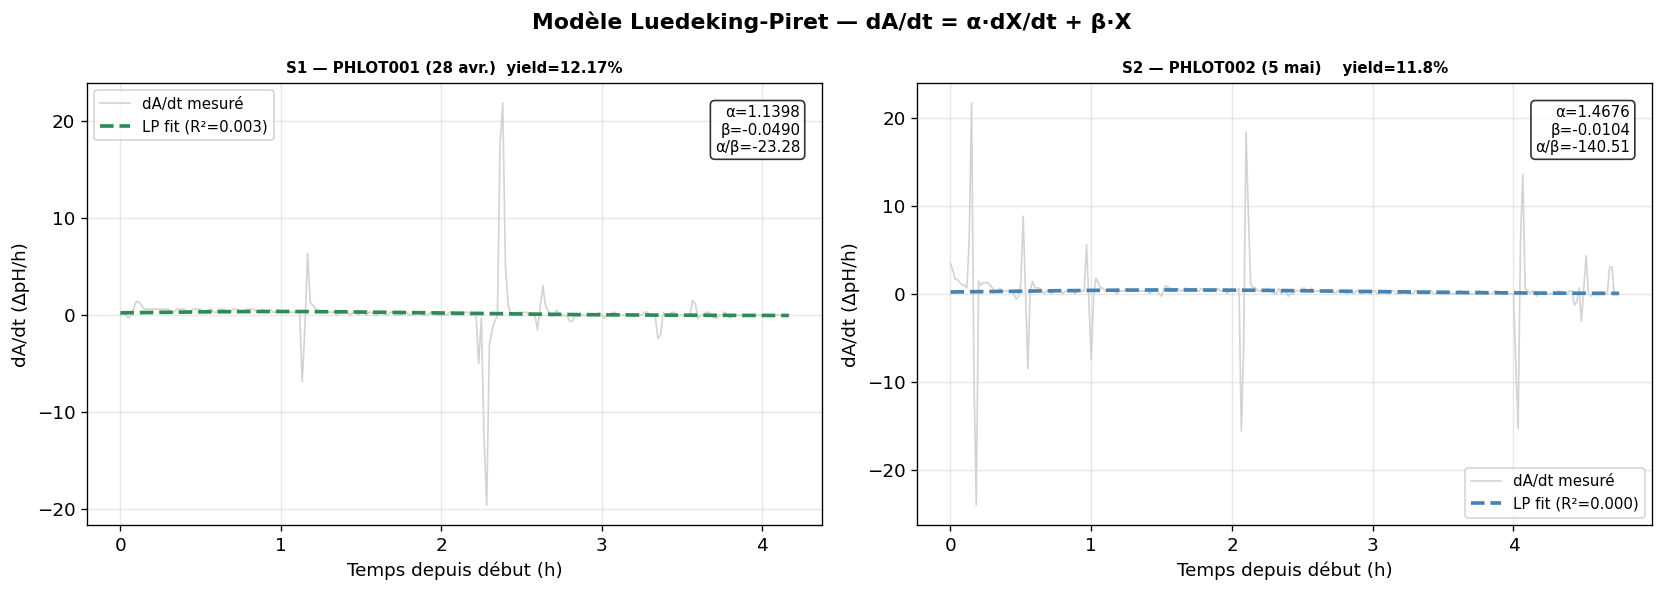

In [4]:
def logistic_growth(t, k, t0):
    return 1 / (1 + np.exp(-k * (t - t0)))

def fit_lp(ph_series):
    t = (ph_series.index - ph_series.index[0]).total_seconds() / 3600
    A = np.clip(ph_series.values[0] - ph_series.values, 0, None)
    dAdt = np.gradient(A, t)

    # Fit logistic growth on normalized A
    A_norm = A / A.max() if A.max() > 0 else A
    t0_est = t[np.argmax(np.gradient(A_norm, t))]
    try:
        popt, _ = curve_fit(logistic_growth, t, A_norm,
                            p0=[2.0, t0_est], maxfev=5000)
        k_fit, t0_fit = popt
    except Exception:
        k_fit, t0_fit = 2.0, t0_est

    X    = logistic_growth(t, k_fit, t0_fit)
    dXdt = k_fit * X * (1 - X)

    # Linear regression dAdt = α*dXdt + β*X
    design = np.column_stack([dXdt, X])
    alpha, beta = np.linalg.lstsq(design, dAdt, rcond=None)[0]
    dAdt_pred = alpha * dXdt + beta * X
    ss_res = np.sum((dAdt - dAdt_pred)**2)
    ss_tot = np.sum((dAdt - dAdt.mean())**2)
    r2 = 1 - ss_res/ss_tot

    return dict(alpha=alpha, beta=beta, r2=r2,
                t=t, dAdt=dAdt, dAdt_pred=dAdt_pred, X=X)

lp_results = {}
for name, d in SESSIONS.items():
    res = fit_lp(d['series'])
    lp_results[name] = res
    dom = 'croissance (α>β)' if res['alpha'] > res['beta'] else 'stationnaire (β>α)'
    print(f'{name}')
    print(f'  α={res["alpha"]:.4f}  β={res["beta"]:.4f}  α/β={res["alpha"]/res["beta"]:.2f}  R²={res["r2"]:.3f}  → {dom}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, d) in zip(axes, SESSIONS.items()):
    res = lp_results[name]
    ax.plot(res['t'], res['dAdt'],      color='lightgrey', linewidth=1.0, label='dA/dt mesuré')
    ax.plot(res['t'], res['dAdt_pred'], color=d['color'],  linewidth=2.2,
            linestyle='--', label=f'LP fit (R²={res["r2"]:.3f})')
    ax.text(0.97, 0.95,
            f'α={res["alpha"]:.4f}\nβ={res["beta"]:.4f}\nα/β={res["alpha"]/res["beta"]:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Temps depuis début (h)')
    ax.set_ylabel('dA/dt (ΔpH/h)')
    ax.legend(fontsize=9)

plt.suptitle('Modèle Luedeking-Piret — dA/dt = α·dX/dt + β·X', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/m02_luedeking_piret.png', bbox_inches='tight')
plt.show()

---
## 3. Modèle de Monod

$$\mu(t) = \mu_{max} \cdot \frac{S(t)}{K_s + S(t)}$$

Sans données de lactose, on utilise le **substrat résiduel proxy** :

$$S(t) = \text{pH}(t) - \text{pH}_{min} \quad \text{(substrat restant ∝ acidification encore possible)}$$

$$\mu(t) = \frac{dA}{dt} \quad \text{(vitesse instantanée = taux de croissance apparent)}$$

> ⚠️ **Hypothèse forte** : la consommation de lactose est proportionnelle à la chute de pH.

  Monod fit failed: Initial guess is outside of provided bounds
  Monod fit failed: Initial guess is outside of provided bounds


/tmp/ipykernel_334466/3919102418.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


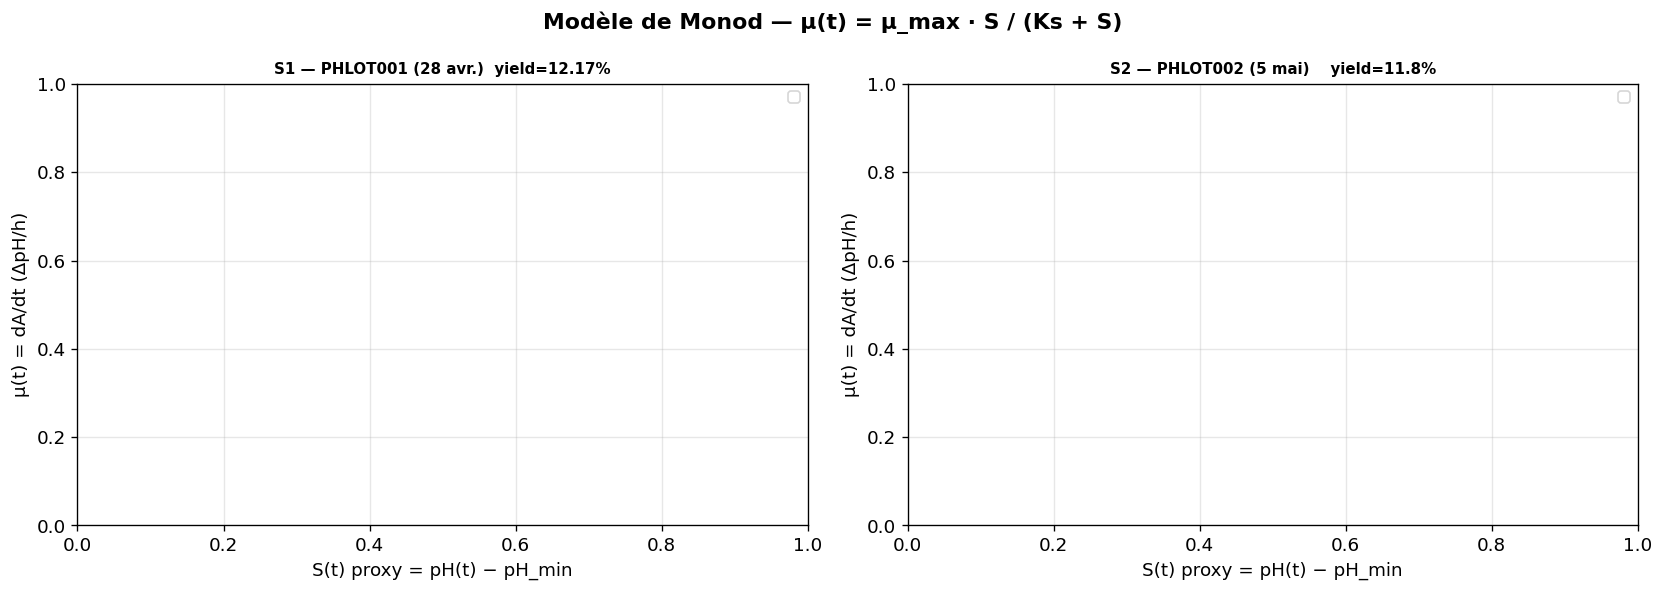

In [5]:
def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

def fit_monod(ph_series):
    t    = (ph_series.index - ph_series.index[0]).total_seconds() / 3600
    pH   = ph_series.values
    pH_min = pH.min()

    S    = pH - pH_min          # substrat résiduel proxy
    dAdt = np.gradient(ph_series.values[0] - pH, t)
    mu   = np.clip(dAdt, 0, None)  # taux de croissance apparent ≥ 0

    # Exclure points où S ≈ 0 (début ou fin)
    mask = S > 0.05
    S_fit, mu_fit = S[mask], mu[mask]

    try:
        popt, _ = curve_fit(monod, S_fit, mu_fit,
                            p0=[mu_fit.max(), np.median(S_fit)],
                            bounds=([0,0],[10,10]), maxfev=10000)
        mu_max, Ks = popt
        mu_pred = monod(S_fit, mu_max, Ks)
        ss_res = np.sum((mu_fit - mu_pred)**2)
        ss_tot = np.sum((mu_fit - mu_fit.mean())**2)
        r2 = 1 - ss_res/ss_tot
        return dict(mu_max=mu_max, Ks=Ks, r2=r2,
                    S=S_fit, mu=mu_fit, mu_pred=mu_pred)
    except Exception as e:
        print(f'  Monod fit failed: {e}')
        return None

monod_results = {}
for name, d in SESSIONS.items():
    res = fit_monod(d['series'])
    if res:
        monod_results[name] = res
        print(f'{name}')
        print(f'  μ_max={res["mu_max"]:.4f} ΔpH/h  Ks={res["Ks"]:.4f} ΔpH  R²={res["r2"]:.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, d) in zip(axes, SESSIONS.items()):
    res = monod_results.get(name)
    if res:
        ax.scatter(res['S'], res['mu'], color='lightgrey', s=12, label='μ(t) observé')
        S_line = np.linspace(res['S'].min(), res['S'].max(), 200)
        ax.plot(S_line, monod(S_line, res['mu_max'], res['Ks']),
                color=d['color'], linewidth=2.2,
                label=f'Monod (R²={res["r2"]:.3f})')
        ax.axvline(res['Ks'], color='orange', linestyle='--', linewidth=1.2,
                   label=f'Ks = {res["Ks"]:.3f}')
        ax.text(0.97, 0.08,
                f'μ_max={res["mu_max"]:.4f}\nKs={res["Ks"]:.4f}',
                transform=ax.transAxes, ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('S(t) proxy = pH(t) − pH_min')
    ax.set_ylabel('μ(t) = dA/dt (ΔpH/h)')
    ax.legend(fontsize=9)

plt.suptitle('Modèle de Monod — μ(t) = μ_max · S / (Ks + S)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/m03_monod.png', bbox_inches='tight')
plt.show()

---
## 4. Comparaison des paramètres entre sessions

In [6]:
yields = {name: d['yield'] for name, d in SESSIONS.items()}

rows = []
for name in SESSIONS:
    g = gompertz_results.get(name, {})
    l = lp_results.get(name, {})
    m = monod_results.get(name, {})
    rows.append({
        'Session':              name.split('|')[0].strip(),
        'Yield (%)':            yields[name],
        # Gompertz
        'G — A_max (ΔpH)':     round(g.get('A_max', np.nan), 3),
        'G — μ_max (ΔpH/h)':   round(g.get('mu_max', np.nan), 3),
        'G — λ (h)':            round(g.get('lam', np.nan), 3),
        'G — R²':               round(g.get('r2', np.nan), 3),
        # Luedeking-Piret
        'LP — α':               round(l.get('alpha', np.nan), 4),
        'LP — β':               round(l.get('beta', np.nan), 4),
        'LP — α/β':             round(l.get('alpha', 0)/l.get('beta', 1), 2) if l.get('beta') else np.nan,
        'LP — R²':              round(l.get('r2', np.nan), 3),
        # Monod
        'M — μ_max':            round(m.get('mu_max', np.nan), 4),
        'M — Ks':               round(m.get('Ks', np.nan), 4),
        'M — R²':               round(m.get('r2', np.nan), 3),
    })

df_summary = pd.DataFrame(rows).set_index('Session')
print('Tableau récapitulatif des paramètres :')
df_summary

Tableau récapitulatif des paramètres :


,Yield (%),G — A_max (ΔpH),G — μ_max (ΔpH/h),G — λ (h),G — R²,LP — α,LP — β,LP — α/β,LP — R²,M — μ_max,M — Ks,M — R²
Session,,,,,,,,,,,,
S1 — PHLOT001 (28 avr.) yield=12.17%,12.17,0.80,0.467,0.0,0.782,1.1398,-0.0490,-23.28,0.003,NaN,NaN,NaN
S2 — PHLOT002 (5 mai) yield=11.8%,11.80,1.31,0.416,0.0,0.942,1.4676,-0.0104,-140.51,0.000,NaN,NaN,NaN


---
## 5. Évaluation Brutale

**Ces modèles sont-ils un outil analytique fiable pour évaluer la qualité du fromage ?**

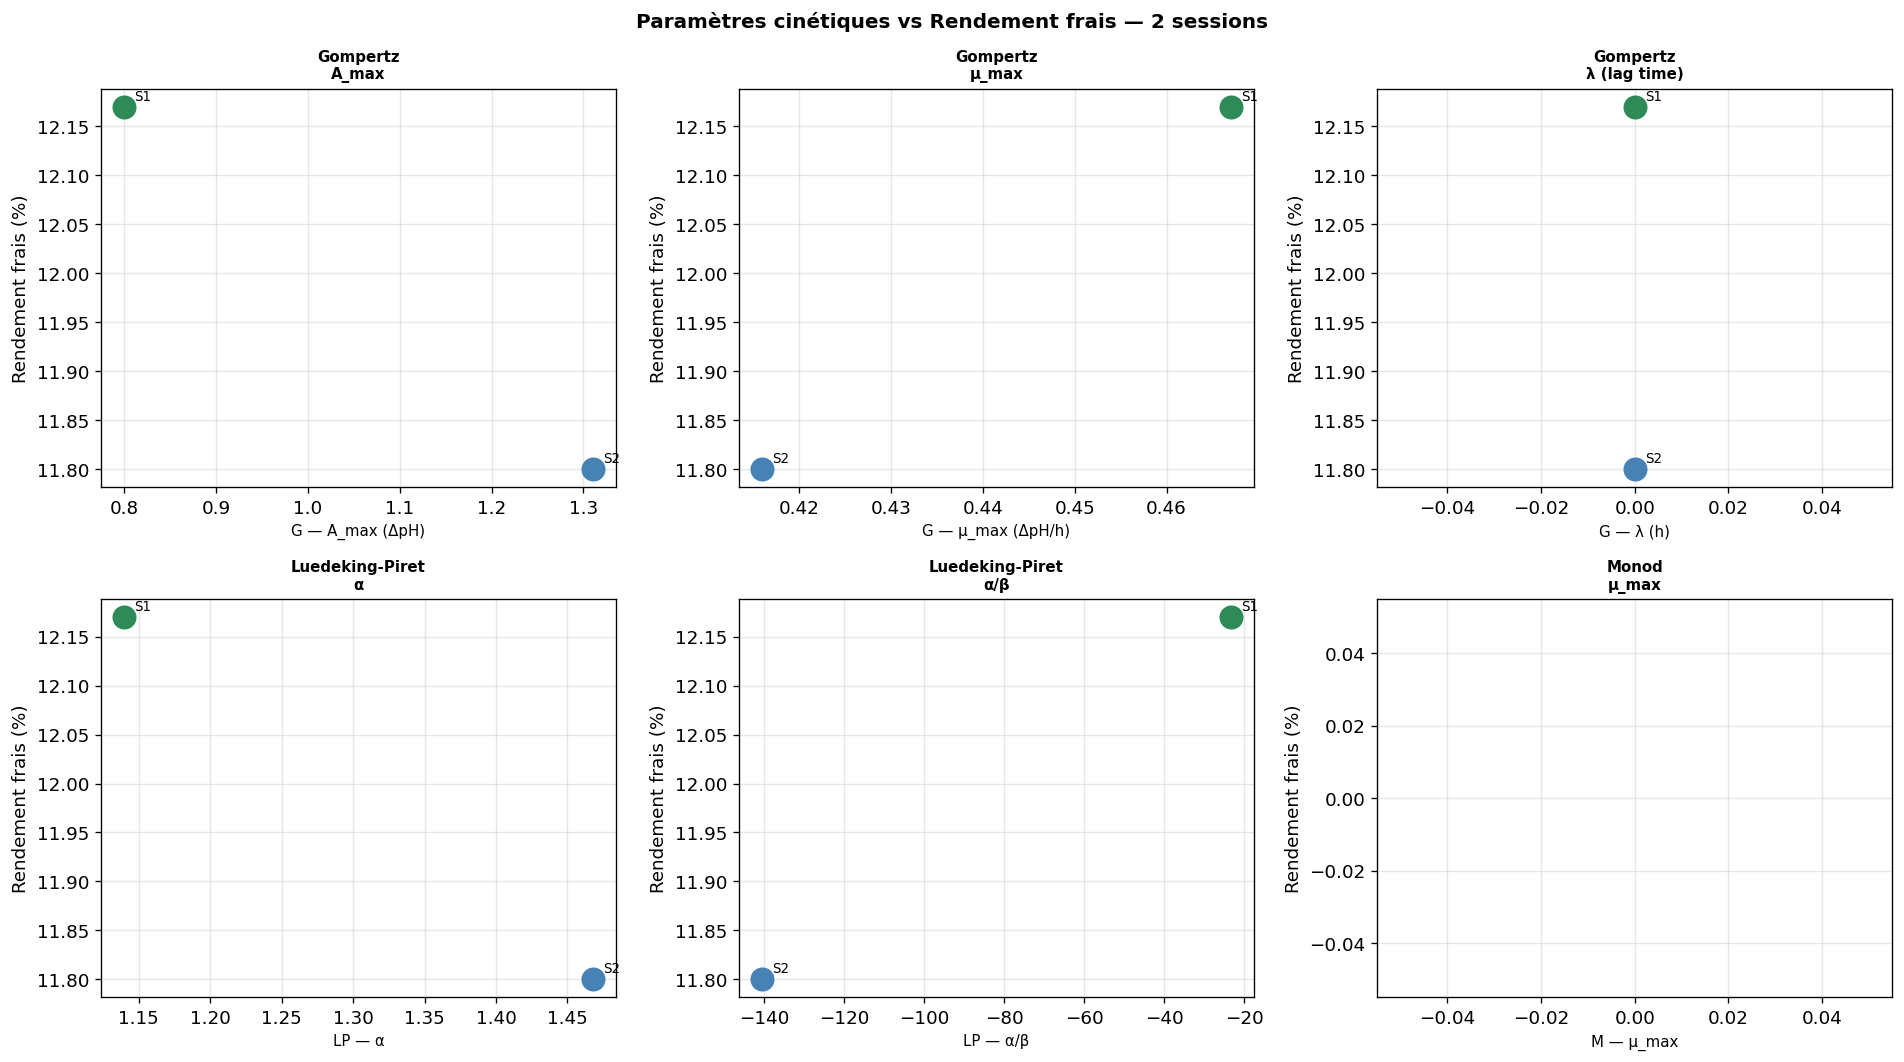

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

params = [
    ('G — A_max (ΔpH)',   'Gompertz\nA_max'),
    ('G — μ_max (ΔpH/h)', 'Gompertz\nμ_max'),
    ('G — λ (h)',          'Gompertz\nλ (lag time)'),
    ('LP — α',             'Luedeking-Piret\nα'),
    ('LP — α/β',           'Luedeking-Piret\nα/β'),
    ('M — μ_max',          'Monod\nμ_max'),
]

colors_plot = [d['color'] for d in SESSIONS.values()]

for ax, (col, label) in zip(axes.flatten(), params):
    x_vals = df_summary[col].values
    y_vals = df_summary['Yield (%)'].values
    for x, y, c, name in zip(x_vals, y_vals, colors_plot, df_summary.index):
        ax.scatter(x, y, color=c, s=180, zorder=5)
        ax.annotate(name.split('—')[0].strip(),
                    (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=8)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Rendement frais (%)')
    ax.set_title(label, fontsize=9, fontweight='bold')

plt.suptitle('Paramètres cinétiques vs Rendement frais — 2 sessions',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/m04_quality_assessment.png', bbox_inches='tight')
plt.show()

---
## 6. Verdict — Ce que ces modèles peuvent et ne peuvent PAS faire

### ✅ Ce qu'ils font bien

| Modèle | Ce qu'il apporte réellement |
|--------|-----------------------------|
| **Gompertz** | Caractérise la **forme** de la courbe : combien d'acide total (A_max), à quelle vitesse max (μ_max), après quel délai (λ). Paramètres reproductibles et comparables entre sessions. |
| **Luedeking-Piret** | Sépare la production d'acide en deux phases biologiques (α vs β). Le ratio α/β indique si la fermentation est dominée par la croissance active ou la phase stationnaire. |
| **Monod** | Donne une estimation de la **capacité maximale de fermentation** (μ_max) et de la sensibilité au substrat résiduel (Ks). |

---

### ❌ Limitations critiques avec seulement 2 sessions

**1. Pas de modèle prédictif possible**  
Avec 2 points, toute droite passe parfaitement — R² = 1 ne signifie rien statistiquement. Il faut **minimum 10–15 sessions** pour une corrélation paramètre → rendement fiable.

**2. Monod repose sur une hypothèse non vérifiée**  
Le substrat proxy `S(t) = pH(t) − pH_min` est une approximation. Sans dosage réel du lactose, le Ks n'a pas de valeur physique absolue — il n'est utile que pour **comparer** des sessions entre elles.

**3. Le rendement dépend de facteurs non capturés par le pH**  
Dose de présure, découpe du caillé, brassage, égouttage — ces facteurs technologiques peuvent masquer la signature cinétique.

---

### 🎯 Verdict final

> Ces trois modèles constituent un **outil de caractérisation** robuste, pas encore un **outil de prédiction** de qualité.  
> Ils permettent de décrire et comparer les fermentations de façon quantitative et reproductible.  
> Pour devenir prédictifs, ils ont besoin de **données de plusieurs sessions** et idéalement de **mesures complémentaires** (lactose, acidité titrable, humidité du fromage).

**Ce qu'il faut collecter dans les prochaines sessions pour débloquer la prédiction :**
- [ ] ≥ 10 sessions avec rendement mesuré
- [ ] Acidité titrable (°Dornic) à t=0, t=2h, t=4h
- [ ] Température enregistrée pour toutes les sondes (pas seulement Hannah)
- [ ] Heure exacte d'ajout du ferment (vrai t=0 de fermentation)